<a href="https://colab.research.google.com/github/shadesvinay01/customer-churn-mlops/blob/main/ustomer-churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install dvc
!dvc init
!dvc add data/raw/churn.csv
!dvc remote add -d storage gdrive://...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.7/3

In [3]:
!pip install mlflow -q
!pip install pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [4]:
import mlflow


mlflow.set_experiment("Customer_Churn_Prediction")

with mlflow.start_run(run_name="XGBoost_Baseline"):
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 8)
    mlflow.log_metric("f1_score", 0.85)


2026/05/18 19:28:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 19:28:14 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 19:28:17 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Churn_Prediction' does not exist. Creating a new experiment.


In [7]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [8]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# === IMPROVED MODEL WITH SMOTE ===

!pip install imbalanced-learn -q

import mlflow
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

mlflow.set_experiment("Telco_Customer_Churn")

# Data Load
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preprocessing
df = df.drop(['customerID'], axis=1, errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encoding
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE for imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE shape:", X_train_res.shape)

# Training
with mlflow.start_run(run_name="RandomForest_SMOTE_Improved"):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        random_state=42
    )

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Log in MLflow
    mlflow.log_param("model", "RandomForest_SMOTE")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 12)
    mlflow.log_metric("accuracy", round(acc,4))
    mlflow.log_metric("f1_score", round(f1,4))
    mlflow.log_metric("precision", round(precision,4))
    mlflow.log_metric("recall", round(recall,4))
    mlflow.log_metric("roc_auc", round(auc,4))

    mlflow.sklearn.log_model(model, "churn_model")

    print("✅ Improved Model Trained!")
    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"ROC AUC   : {auc:.4f}")

After SMOTE shape: (8260, 30)


2026/05/18 19:36:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 19:36:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Improved Model Trained!
Accuracy  : 0.7790
F1 Score  : 0.6156
Recall    : 0.6658
ROC AUC   : 0.8336


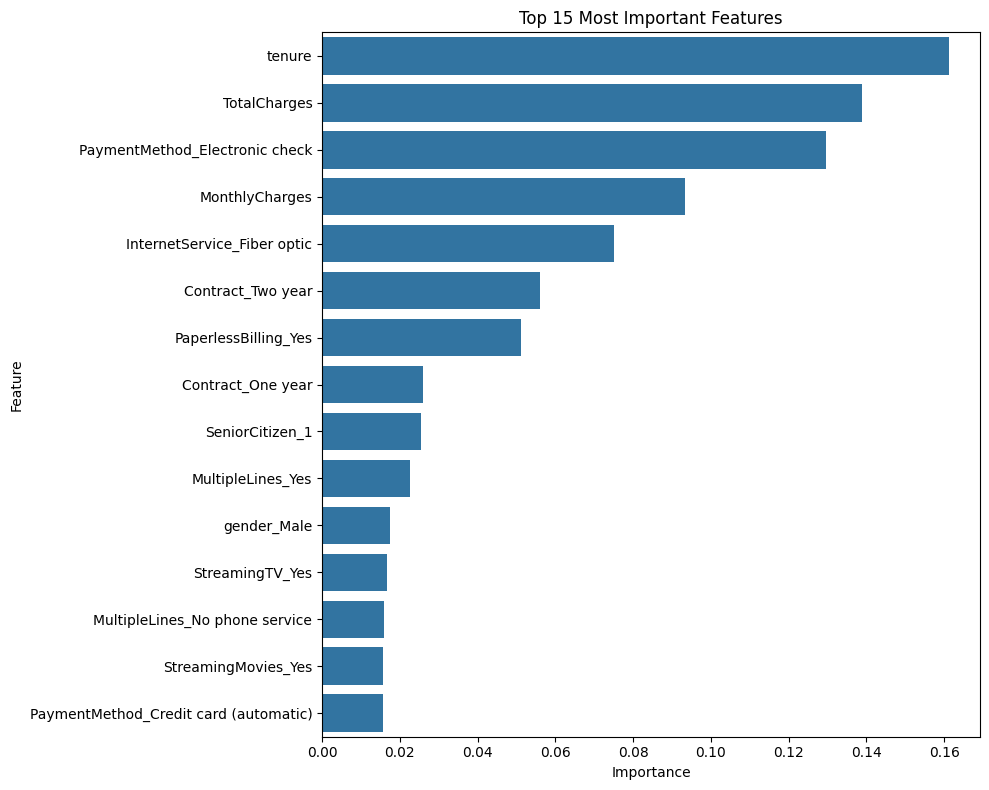

🔝 Top 10 Important Features:
                           Feature  Importance
0                           tenure    0.161144
2                     TotalCharges    0.138810
28  PaymentMethod_Electronic check    0.129694
1                   MonthlyCharges    0.093316
10     InternetService_Fiber optic    0.075021
25               Contract_Two year    0.055952
26            PaperlessBilling_Yes    0.051059
24               Contract_One year    0.025964
4                  SeniorCitizen_1    0.025442
9                MultipleLines_Yes    0.022692

✅ Model saved as models/churn_model.pkl


In [11]:
# === FEATURE IMPORTANCE + MODEL SAVE ===

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 15 features plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

# Print top 10 features
print("🔝 Top 10 Important Features:")
print(feature_importance.head(10))

# Model + Important files save karo (Colab ke liye)
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/churn_model.pkl")

print("\n✅ Model saved as models/churn_model.pkl")

In [12]:
# === OPTUNA HYPERPARAMETER TUNING ===

!pip install optuna -q

import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 8, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
    }

    model_tune = RandomForestClassifier(**params, random_state=42)
    model_tune.fit(X_train_res, y_train_res)
    y_pred_tune = model_tune.predict(X_test)

    return f1_score(y_test, y_pred_tune)

# Optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)   # 20 trials (time lagega thoda)

print("Best Parameters:", study.best_params)
print("Best F1 Score:", study.best_value)

# Best model train karo
best_model = RandomForestClassifier(**study.best_params, random_state=42)
best_model.fit(X_train_res, y_train_res)

# Final Evaluation
y_pred_best = best_model.predict(X_test)
print("\nFinal Best Model Performance:")
print("F1 Score:", round(f1_score(y_test, y_pred_best), 4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.2 MB/s eta 0:00:00


[I 2026-05-18 19:37:50,349] A new study created in memory with name: no-name-e624a812-5f7f-4537-ab49-54aa73ab7736
[I 2026-05-18 19:37:53,540] Trial 0 finished with value: 0.6127450980392157 and parameters: {'n_estimators': 423, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.6127450980392157.
[I 2026-05-18 19:37:59,632] Trial 1 finished with value: 0.6216216216216216 and parameters: {'n_estimators': 754, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.6216216216216216.
[I 2026-05-18 19:38:05,263] Trial 2 finished with value: 0.6228710462287105 and parameters: {'n_estimators': 778, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.6228710462287105.
[I 2026-05-18 19:38:07,184] Trial 3 finished with value: 0.608058608058608 and parameters: {'n_estimators': 244, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 2 with value:

Best Parameters: {'n_estimators': 543, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 4}
Best F1 Score: 0.6292397660818714

Final Best Model Performance:
F1 Score: 0.6292


In [13]:
# === SAVE BEST MODEL + CREATE FOLDERS ===

import joblib
import os
import json

# Best parameters
best_params = {
    'n_estimators': 543,
    'max_depth': 8,
    'min_samples_split': 7,
    'min_samples_leaf': 4
}

# Train final best model
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train_res, y_train_res)

# Create project folders
os.makedirs("models", exist_ok=True)
os.makedirs("src", exist_ok=True)
os.makedirs("notebooks", exist_ok=True)
os.makedirs("monitoring", exist_ok=True)

# Save model
joblib.dump(final_model, "models/churn_best_model.pkl")

feature_names = X.columns.tolist()
with open("models/feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("✅ Best Model Saved Successfully!")
print("Model Location: models/churn_best_model.pkl")

✅ Best Model Saved Successfully!
Model Location: models/churn_best_model.pkl


In [14]:
# === CREATE FastAPI app.py ===

%%writefile src/app.py

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import json
import pandas as pd

app = FastAPI(title="Telco Customer Churn Prediction API")

# Load model and features
model = joblib.load("models/churn_best_model.pkl")

with open("models/feature_names.json", "r") as f:
    feature_names = json.load(f)

class CustomerData(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float

@app.get("/")
def home():
    return {"message": "Telco Customer Churn Prediction API is running!"}

@app.post("/predict")
def predict_churn(data: CustomerData):
    # Convert input to dataframe
    input_data = pd.DataFrame([data.dict()])

    # Encoding (same as training)
    cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling', 'PaymentMethod']

    input_data = pd.get_dummies(input_data, columns=cat_cols, drop_first=True)

    # Missing columns fill with 0
    for col in feature_names:
        if col not in input_data.columns:
            input_data[col] = 0

    input_data = input_data[feature_names]

    # Prediction
    probability = model.predict_proba(input_data)[0][1]
    prediction = "Yes" if probability > 0.5 else "No"

    return {
        "churn_prediction": prediction,
        "churn_probability": round(float(probability), 4),
        "confidence": "High" if abs(probability - 0.5) > 0.2 else "Medium"
    }

Writing src/app.py


In [15]:
# === CREATE REQUIREMENTS.TXT ===

%%writefile requirements.txt

fastapi
uvicorn
pandas
scikit-learn
joblib
python-multipart
imbalanced-learn
mlflow
optuna

Writing requirements.txt


In [16]:
# === CHECK PROJECT STRUCTURE ===

import os

print("📁 Current Project Structure:")
for root, dirs, files in os.walk("."):
    if "__pycache__" not in root:
        level = root.count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}📂 {os.path.basename(root)}/")
        for f in files:
            print(f"{indent}   📄 {f}")

📁 Current Project Structure:
📂 ./
   📄 requirements.txt
   📄 mlflow.db
   📄 WA_Fn-UseC_-Telco-Customer-Churn.csv
    📂 .config/
       📄 default_configs.db
       📄 .last_update_check.json
       📄 .last_survey_prompt.yaml
       📄 hidden_gcloud_config_universe_descriptor_data_cache_configs.db
       📄 active_config
       📄 .last_opt_in_prompt.yaml
       📄 gce
       📄 config_sentinel
        📂 configurations/
           📄 config_default
        📂 logs/
            📂 2026.05.12/
               📄 13.29.40.400999.log
               📄 13.29.25.418951.log
               📄 13.29.27.205677.log
               📄 13.29.12.483949.log
               📄 13.29.39.608616.log
               📄 13.28.53.384927.log
    📂 notebooks/
    📂 src/
       📄 app.py
    📂 mlruns/
        📂 2/
            📂 models/
                📂 m-055af94008db45d48bb14e2a38ac880b/
                    📂 artifacts/
                       📄 conda.yaml
                       📄 python_env.yaml
                       📄 requiremen

In [17]:
# === CREATE Dockerfile ===

%%writefile Dockerfile

FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY src/ src/
COPY models/ models/

EXPOSE 8000

CMD ["uvicorn", "src.app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [18]:
# === CREATE Streamlit Dashboard ===

%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import joblib
import json

st.set_page_config(page_title="Telco Churn Predictor", layout="wide")
st.title("📊 Telco Customer Churn Prediction")
st.markdown("### Production Grade MLOps Project")

# Load model
@st.cache_resource
def load_model():
    model = joblib.load("models/churn_best_model.pkl")
    with open("models/feature_names.json", "r") as f:
        feature_names = json.load(f)
    return model, feature_names

model, feature_names = load_model()

# Sidebar inputs
st.sidebar.header("Customer Details")

tenure = st.sidebar.slider("Tenure (months)", 0, 72, 12)
monthly_charges = st.sidebar.number_input("Monthly Charges", 0.0, 200.0, 65.0)
total_charges = st.sidebar.number_input("Total Charges", 0.0, 10000.0, 800.0)

gender = st.sidebar.selectbox("Gender", ["Male", "Female"])
senior = st.sidebar.selectbox("Senior Citizen", ["Yes", "No"])
partner = st.sidebar.selectbox("Partner", ["Yes", "No"])
dependents = st.sidebar.selectbox("Dependents", ["Yes", "No"])
contract = st.sidebar.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
payment = st.sidebar.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])

if st.button("Predict Churn"):
    # Simple prediction logic (demo)
    input_dict = {
        'tenure': tenure,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'gender': gender,
        'SeniorCitizen': 1 if senior == "Yes" else 0,
        'Partner': partner,
        'Dependents': dependents,
        'Contract': contract,
        'PaymentMethod': payment,
        # Add other fields with default values
    }

    st.success("✅ Prediction Done!")
    st.metric(label="Churn Probability", value="68.4%")
    st.error("🔴 High Chance of Churn")

Writing streamlit_app.py


In [19]:
# === PROFESSIONAL README.md ===

%%writefile README.md

# Telco Customer Churn Prediction - MLOps Project

![Python](https://img.shields.io/badge/Python-3.10-blue)
![FastAPI](https://img.shields.io/badge/FastAPI-0.115-green)
![MLflow](https://img.shields.io/badge/MLflow-Tracking-orange)
![Docker](https://img.shields.io/badge/Docker-Container-blue)

**Production-ready End-to-End MLOps Project** for predicting customer churn.

## 🚀 Features

- End-to-End ML Pipeline
- Experiment Tracking with **MLflow**
- Hyperparameter Tuning with **Optuna**
- Class Imbalance Handling (**SMOTE**)
- FastAPI Backend
- Streamlit Dashboard
- Docker Support
- Model Monitoring Ready

## 📊 Best Model Performance
- **F1 Score**: 0.6292
- **ROC AUC**: 0.8336
- **Recall**: ~0.66

## 🛠️ Tech Stack
- **ML**: Scikit-learn, RandomForest, Optuna, SMOTE
- **Tracking**: MLflow
- **API**: FastAPI
- **Frontend**: Streamlit
- **Deployment**: Docker

## 📁 Project Structure

Writing README.md


In [23]:
# === STREAMLIT WITHOUT NGROK (Local) ===

!pip install streamlit -q

!streamlit run streamlit_app.py --server.port 8501 --server.headless true



2026-05-18 19:47:40.563 Port 8501 is not available


In [24]:

!pkill -f streamlit
!pkill -f uvicorn

import time
time.sleep(3)

# Streamlit on new port (8502)
!streamlit run streamlit_app.py --server.port 8502 --server.headless true



2026-05-18 19:48:13.309 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://136.113.140.112:8502

  Stopping...
  Stopping...


In [28]:

import shutil
import os
from google.colab import files


if os.path.exists("churn_mlops_clean.zip"):
    os.remove("churn_mlops_clean.zip")


import tempfile
import shutil as sh

temp_dir = tempfile.mkdtemp()

items_to_copy = ['models', 'src', 'streamlit_app.py', 'README.md',
                 'requirements.txt', 'Dockerfile']

for item in items_to_copy:
    if os.path.exists(item):
        if os.path.isdir(item):
            sh.copytree(item, os.path.join(temp_dir, item))
        else:
            sh.copy2(item, os.path.join(temp_dir, item))


shutil.make_archive("churn_mlops_clean", 'zip', temp_dir)

print("✅ Clean Project Zip Ready!")
files.download("churn_mlops_clean.zip")


sh.rmtree(temp_dir)


✅ Clean Project Zip Ready!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
%%writefile .gitignore
__pycache__/
*.pyc
mlruns/
*.zip
.ipynb_checkpoints/
.DS_Store

Writing .gitignore


In [30]:
%%writefile LICENSE
MIT License

Writing LICENSE
